In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [2]:
with open('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/imb_files/final_hpt_choices.pkl', 'rb') as f:
    final_choices = pickle.load(f)

In [3]:
class_names = ['void', 'non-void']

In [4]:
files = [
    '3s_no.csv',
    '5s_no.csv',
    '5s_0.5.csv',
    '2s_0.5.csv',
]

train_data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/working_data/'
test_data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/meta_test_data/'

Analysing 3s_no


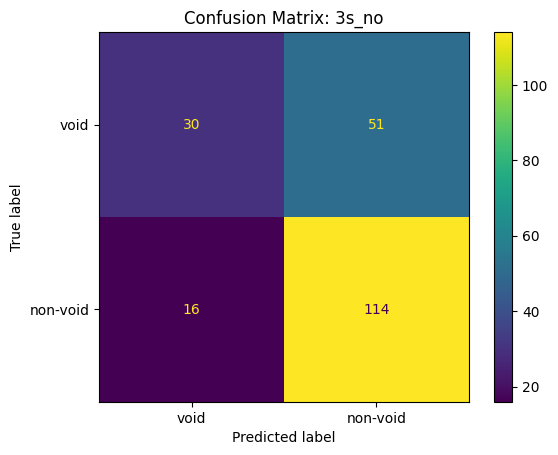

Classification Report: 3s_no 
              precision    recall  f1-score   support

        void       0.65      0.37      0.47        81
    non-void       0.69      0.88      0.77       130

    accuracy                           0.68       211
   macro avg       0.67      0.62      0.62       211
weighted avg       0.68      0.68      0.66       211

Accuracy: 0.6824644549763034
Analysing 5s_no


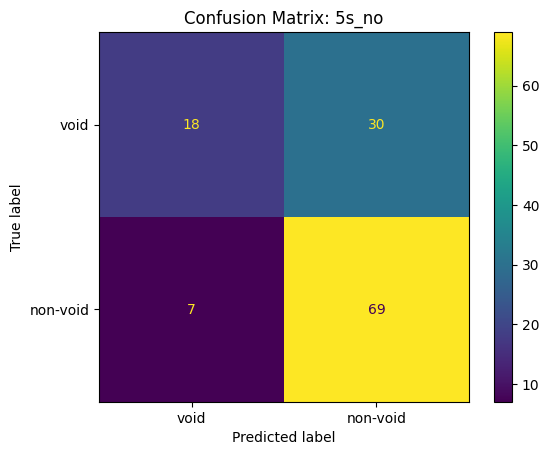

Classification Report: 5s_no 
              precision    recall  f1-score   support

        void       0.72      0.38      0.49        48
    non-void       0.70      0.91      0.79        76

    accuracy                           0.70       124
   macro avg       0.71      0.64      0.64       124
weighted avg       0.71      0.70      0.67       124

Accuracy: 0.7016129032258065
Analysing 5s_0.5


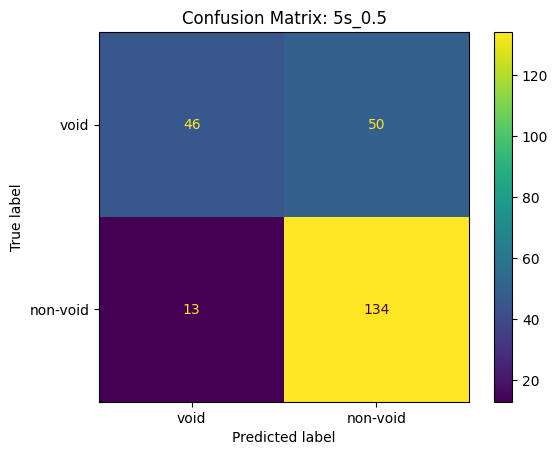

Classification Report: 5s_0.5 
              precision    recall  f1-score   support

        void       0.78      0.48      0.59        96
    non-void       0.73      0.91      0.81       147

    accuracy                           0.74       243
   macro avg       0.75      0.70      0.70       243
weighted avg       0.75      0.74      0.72       243

Accuracy: 0.7407407407407407
Analysing 2s_0.5


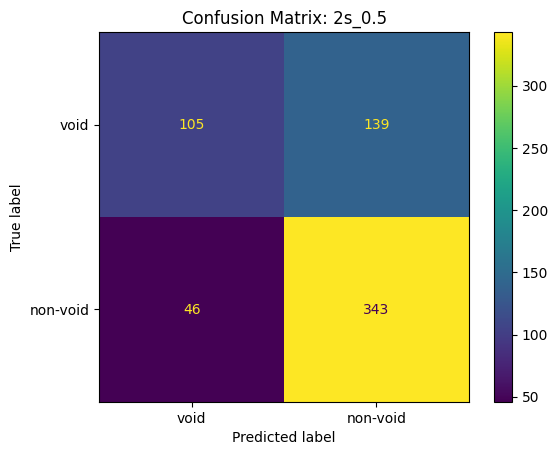

Classification Report: 2s_0.5 
              precision    recall  f1-score   support

        void       0.70      0.43      0.53       244
    non-void       0.71      0.88      0.79       389

    accuracy                           0.71       633
   macro avg       0.70      0.66      0.66       633
weighted avg       0.71      0.71      0.69       633

Accuracy: 0.707740916271722


In [ ]:
for file in files:
    train_data = pd.read_csv(train_data_path + file)
    test_data = pd.read_csv(test_data_path + file)
    details = file.split('_')
    exp_name = f"{details[0]}_{details[-1].replace('.csv', '')}"
    print(f"Analysing {exp_name}")
    
    
    X_train = train_data.drop(columns=['label', 'experiment_id'])
    y_train = train_data['label']
    groups_train = train_data['experiment_id']

    X_test = test_data.drop(columns=['label', 'experiment_id'])
    y_test = test_data['label']
    groups_test = test_data['experiment_id']
    
    tuned_model_imb_params = final_choices[exp_name]
    params = tuned_model_imb_params['params']
    
    # Model selection
    if tuned_model_imb_params['model'] == 'xgb':
        model = XGBClassifier(
            n_estimators=int(params['n_estimators']),
            learning_rate=params['learning_rate'],
            max_depth=int(params['max_depth']),
            min_child_weight=params['min_child_weight'],
            gamma=params['gamma'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            colsample_bytree=params['colsample_bytree'],
            # use_label_encoder=False,
            eval_metric='logloss'
        )
        
    elif tuned_model_imb_params['model'] == 'rf':
        model = RandomForestClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            min_samples_split=int(params['min_samples_split']),
            min_samples_leaf=int(params['min_samples_leaf']),
            max_features=params['max_features'],
            bootstrap=params['bootstrap']
        )
        
    # Imb selection
    if tuned_model_imb_params['imbalance_technique'] == 'smote':
        sampler = SMOTE(random_state=42)
    elif tuned_model_imb_params['imbalance_technique'] == 'tomek':
        sampler = TomekLinks()
    elif tuned_model_imb_params['imbalance_technique'] == 'smote_tomek':
        sampler = SMOTETomek(random_state=42)
        
    # Apply the sampler
    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

    # Encode labels
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_resampled)
        
    model.fit(X_train_resampled, y_train_encoded)
    y_pred = label_encoder.inverse_transform(model.predict(X_test))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_names)
    cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['void', 'non-void'])
    cm_display.plot()
    plt.title(f'Confusion Matrix: {exp_name}')
    plt.show()
    
    
    print(f"Classification Report: {exp_name} ")
    print(classification_report(y_test, y_pred, labels=class_names))
    print("Accuracy:", accuracy_score(y_test, y_pred))